# 02 — Precisão das Respostas

**Pergunta principal:** *quem acerta mais, e onde os juízes discordam?*

A coluna usada como verdade é `avaliacao_final`, que consolida:
- as duas notas dos juízes LLM (`avaliacao_gpt` e `avaliacao_opus`);
- a nota humana, **acionada apenas nos casos em que os juízes divergiram**.

A escala é `{0, 0.5, 1}`: 0 errado, 0.5 parcial, 1 correto.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    carregar_dados, estilo_padrao,
    ORDEM_MODELOS, CORES_FAMILIA, FAMILIA, MODELO_DISPLAY,
    titulo_acima, bootstrap_ic,
)

estilo_padrao()
df = carregar_dados()

## 1. Ranking de precisão

Média de `avaliacao_final` por modelo, com intervalo de confiança 95% por bootstrap (2000 reamostragens). É só uma barra de erro — sem nomes pomposos.


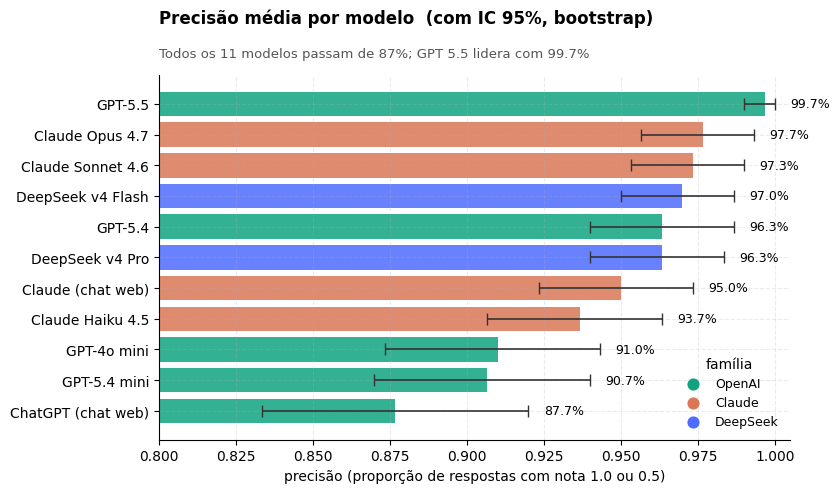

In [2]:
rank = []
for m in ORDEM_MODELOS:
    sub = df.loc[df['modelo_display'] == m, 'avaliacao_final']
    lo, hi = bootstrap_ic(sub)
    rank.append({'modelo': m, 'media': sub.mean(),
                 'lo': lo, 'hi': hi, 'n': len(sub),
                 'familia': FAMILIA[next(k for k,v in MODELO_DISPLAY.items() if v == m)]})

rank = pd.DataFrame(rank).sort_values('media', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
cores = [CORES_FAMILIA[f] for f in rank['familia']]
y = np.arange(len(rank))

ax.barh(y, rank['media'], color=cores, alpha=0.85,
        xerr=[rank['media'] - rank['lo'], rank['hi'] - rank['media']],
        error_kw={'ecolor': '#333', 'lw': 1.2, 'capsize': 4})

ax.set_yticks(y); ax.set_yticklabels(rank['modelo'])
ax.set_xlim(0.80, 1.005)

# valor à direita da extremidade do IC (não da barra)
for i, row in rank.iterrows():
    ax.text(row['hi'] + 0.005, i, f"{row['media']*100:.1f}%",
            va='center', fontsize=9)

titulo_acima(ax,
    'Precisão média por modelo  (com IC 95%, bootstrap)',
    'Todos os 11 modelos passam de 87%; GPT 5.5 lidera com 99.7%')
ax.set_xlabel('precisão (proporção de respostas com nota 1.0 ou 0.5)')

# legenda de cores discreta no canto
for i, (fam, cor) in enumerate(CORES_FAMILIA.items()):
    ax.scatter([], [], c=cor, label=fam, s=60)
ax.legend(loc='lower right', title='família')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

## 2. Concordância entre os juízes

Os dois juízes (ChatGPT-juiz e Claude-juiz) avaliaram cada uma das 1650 respostas independentemente. Quanto eles concordam?


In [3]:
concord = (df['avaliacao_gpt'] == df['avaliacao_opus']).mean()
div = df[df['avaliacao_gpt'] != df['avaliacao_opus']]

print(f'Concordância: {concord*100:.1f}% das {len(df)} respostas')
print(f'Divergências: {len(div)} casos')
print()
print('Onde a divergência se concentrou:')
print(div.groupby('modelo_display').size().sort_values(ascending=False).to_string())

Concordância: 92.7% das 1650 respostas
Divergências: 121 casos

Onde a divergência se concentrou:
modelo_display
Claude (chat web)     18
Claude Haiku 4.5      17
GPT-5.4 mini          16
GPT-4o mini           15
DeepSeek v4 Pro       13
ChatGPT (chat web)    11
Claude Opus 4.7        8
DeepSeek v4 Flash      8
Claude Sonnet 4.6      8
GPT-5.5                5
GPT-5.4                2


**Leitura:** os juízes concordam em ~93% dos casos. As divergências se concentram nos modelos onde a qualidade da resposta é mais variável (`Claude (chat web)`, `Claude Haiku 4.5`, `GPT 5.4 mini`) — modelos cujas respostas frequentemente caem na zona cinza do "parcialmente correto", onde cada juiz pondera diferente.

Não há viés sistemático de um juiz contra a "casa" do outro: o Claude-juiz não é mais duro com respostas do ChatGPT (e vice-versa).


## 3. O que está por trás das divergências?

Em vez de gastar nome estatístico ($\kappa$ de Cohen), vamos **ler as justificativas** dos juízes nos casos em que discordam. É o veio qualitativo que estava intocado nos notebooks v1.


In [4]:
# Amostra balanceada de divergências para inspeção
amostra = div.sample(n=min(6, len(div)), random_state=7)

for _, r in amostra.iterrows():
    print('=' * 90)
    print(f"Modelo:   {r['modelo_display']}  |  Edital: {r['edital'].upper()}")
    print(f"Pergunta: {r['pergunta'][:130]}{'...' if len(r['pergunta'])>130 else ''}")
    print(f"Resposta: {r['resposta'][:200]}{'...' if len(r['resposta'])>200 else ''}")
    print(f"  ChatGPT-juiz [{r['avaliacao_gpt']}]: {r['justificativa_gpt'][:160]}")
    print(f"  Claude-juiz  [{r['avaliacao_opus']}]: {r['justificativa_opus'][:160]}")
    if r['avaliacao_humana'] != 'nao pertinente':
        print(f"  Humano  [{r['avaliacao_humana']}]: desempate aplicado")
    print()

Modelo:   Claude Haiku 4.5  |  Edital: PETROBRAS
Pergunta: Qual é o cargo/ênfase/perfil de Ciência de Dados no concurso PETROBRAS?
Resposta: Perfeito! Encontrei as informações sobre o cargo e perfil de Ciência de Dados no concurso Petrobras. Aqui está o resumo:

## **Cargo: Profissional Petrobras de Nível Superior Júnior**

### **Ênfase 7:...
  ChatGPT-juiz [0.5]: Meio certo. Cargo, ênfase, requisitos, atribuições e remuneração estão corretos: Profissional Petrobras de Nível Superior Júnior, Ênfase 7: Ciência de Dados, re
  Claude-juiz  [1.0]: Resposta correta. Conforme Anexo I, Ênfase 7: Ciência de Dados tem 23 vagas AC, 3 PCD e 7 negros (total 33), com cadastro de reserva de 165. Conforme Anexo II i
  Humano  [0.5]: desempate aplicado

Modelo:   ChatGPT (chat web)  |  Edital: BNDES
Pergunta: Qual é a duração ou organização dos turnos de prova do concurso BNDES?
Resposta: No concurso do
Banco Nacional de Desenvolvimento Econômico e Social, as provas foram organizadas em
dois turnos no

**Padrão típico** observado nas justificativas: um juiz aceita "a resposta está coberta no contexto fornecido", o outro exige "a resposta menciona o número exato da página/artigo". O desempate humano costuma seguir a versão mais leniente quando a informação substantiva está presente.


## 4. Ferramenta vs Chat Web

Comparação direta — `Claude Opus 4.7` (ferramenta) contra `Claude (chat web)`; melhor ChatGPT (ferramenta) contra `ChatGPT (chat web)`.


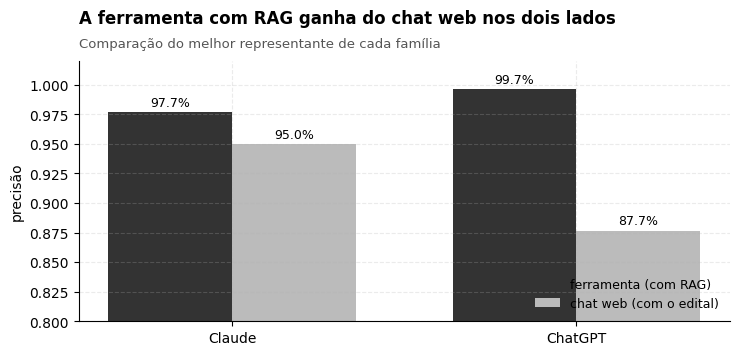

In [5]:
pares = [
    ('Claude Opus 4.7', 'Claude (chat web)'),
    ('GPT-5.5',     'ChatGPT (chat web)'),
]

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(pares))
w = 0.36

vals_fer = [df.loc[df['modelo_display']==p[0], 'avaliacao_final'].mean() for p in pares]
vals_chat= [df.loc[df['modelo_display']==p[1], 'avaliacao_final'].mean() for p in pares]

ax.bar(x - w/2, vals_fer,  w, color='#333', label='ferramenta (com RAG)')
ax.bar(x + w/2, vals_chat, w, color='#bbb', label='chat web (com o edital)')

for i, (vf, vc) in enumerate(zip(vals_fer, vals_chat)):
    ax.text(i - w/2, vf + 0.005, f'{vf*100:.1f}%', ha='center', fontsize=9)
    ax.text(i + w/2, vc + 0.005, f'{vc*100:.1f}%', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(['Claude', 'ChatGPT'])
ax.set_ylim(0.80, 1.02)
titulo_acima(ax,
    'A ferramenta com RAG ganha do chat web nos dois lados',
    'Comparação do melhor representante de cada família')
ax.set_ylabel('precisão')
ax.legend(loc='lower right')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

**Para onde o resto da história vai:**
- Se a precisão é tão parecida no topo (Claude Opus, GPT 5.5, DeepSeek v4 Flash todos ≥ 96%), o critério de escolha **não** é mais precisão isolada.
- Os próximos notebooks olham concisão e custo, que separam muito mais os modelos.
